In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [2]:
df = pd.read_csv("kc_house_data.csv")

In [3]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [4]:
df.drop(columns= ['id', 'zipcode', 'lat','long','date'])

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,1530,1509
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,1830,7200
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,1020,2007
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,1410,1287


In [5]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [7]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [8]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


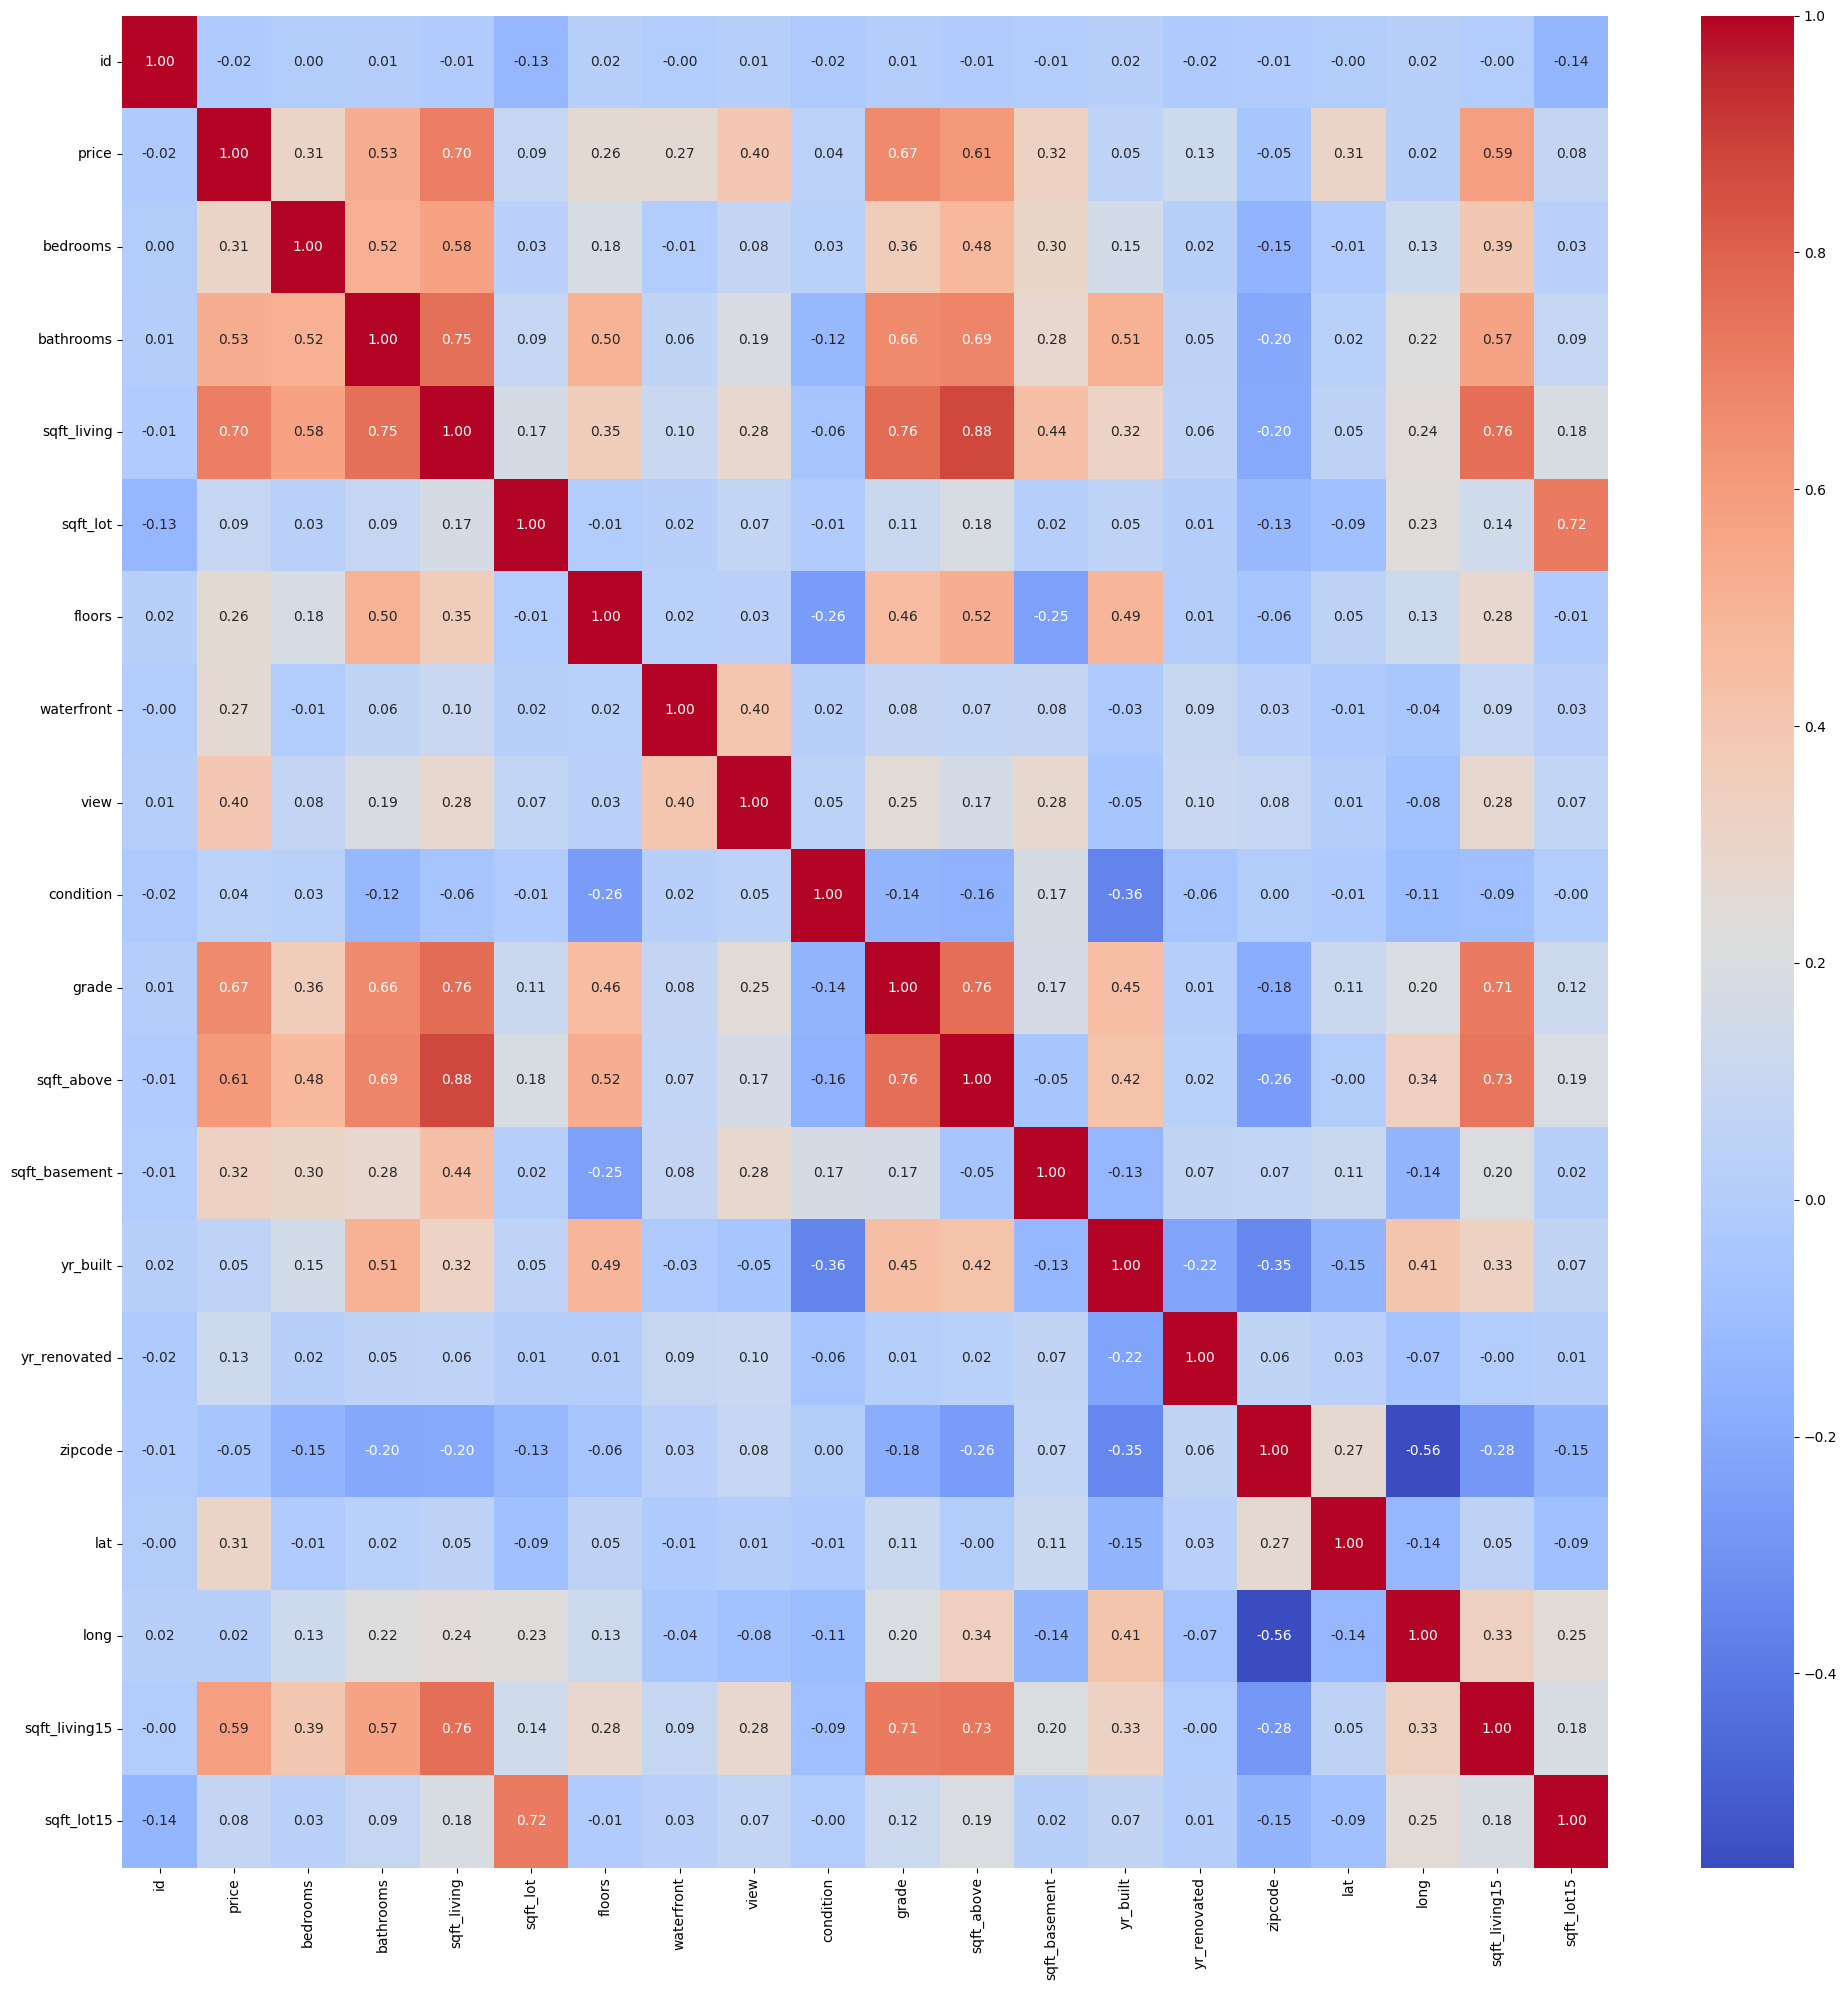

In [9]:
cor = df.select_dtypes(include='number')
n = len(cor.columns)
plt.subplots(figsize=(n, n))
sns.heatmap(cor.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.tight_layout()

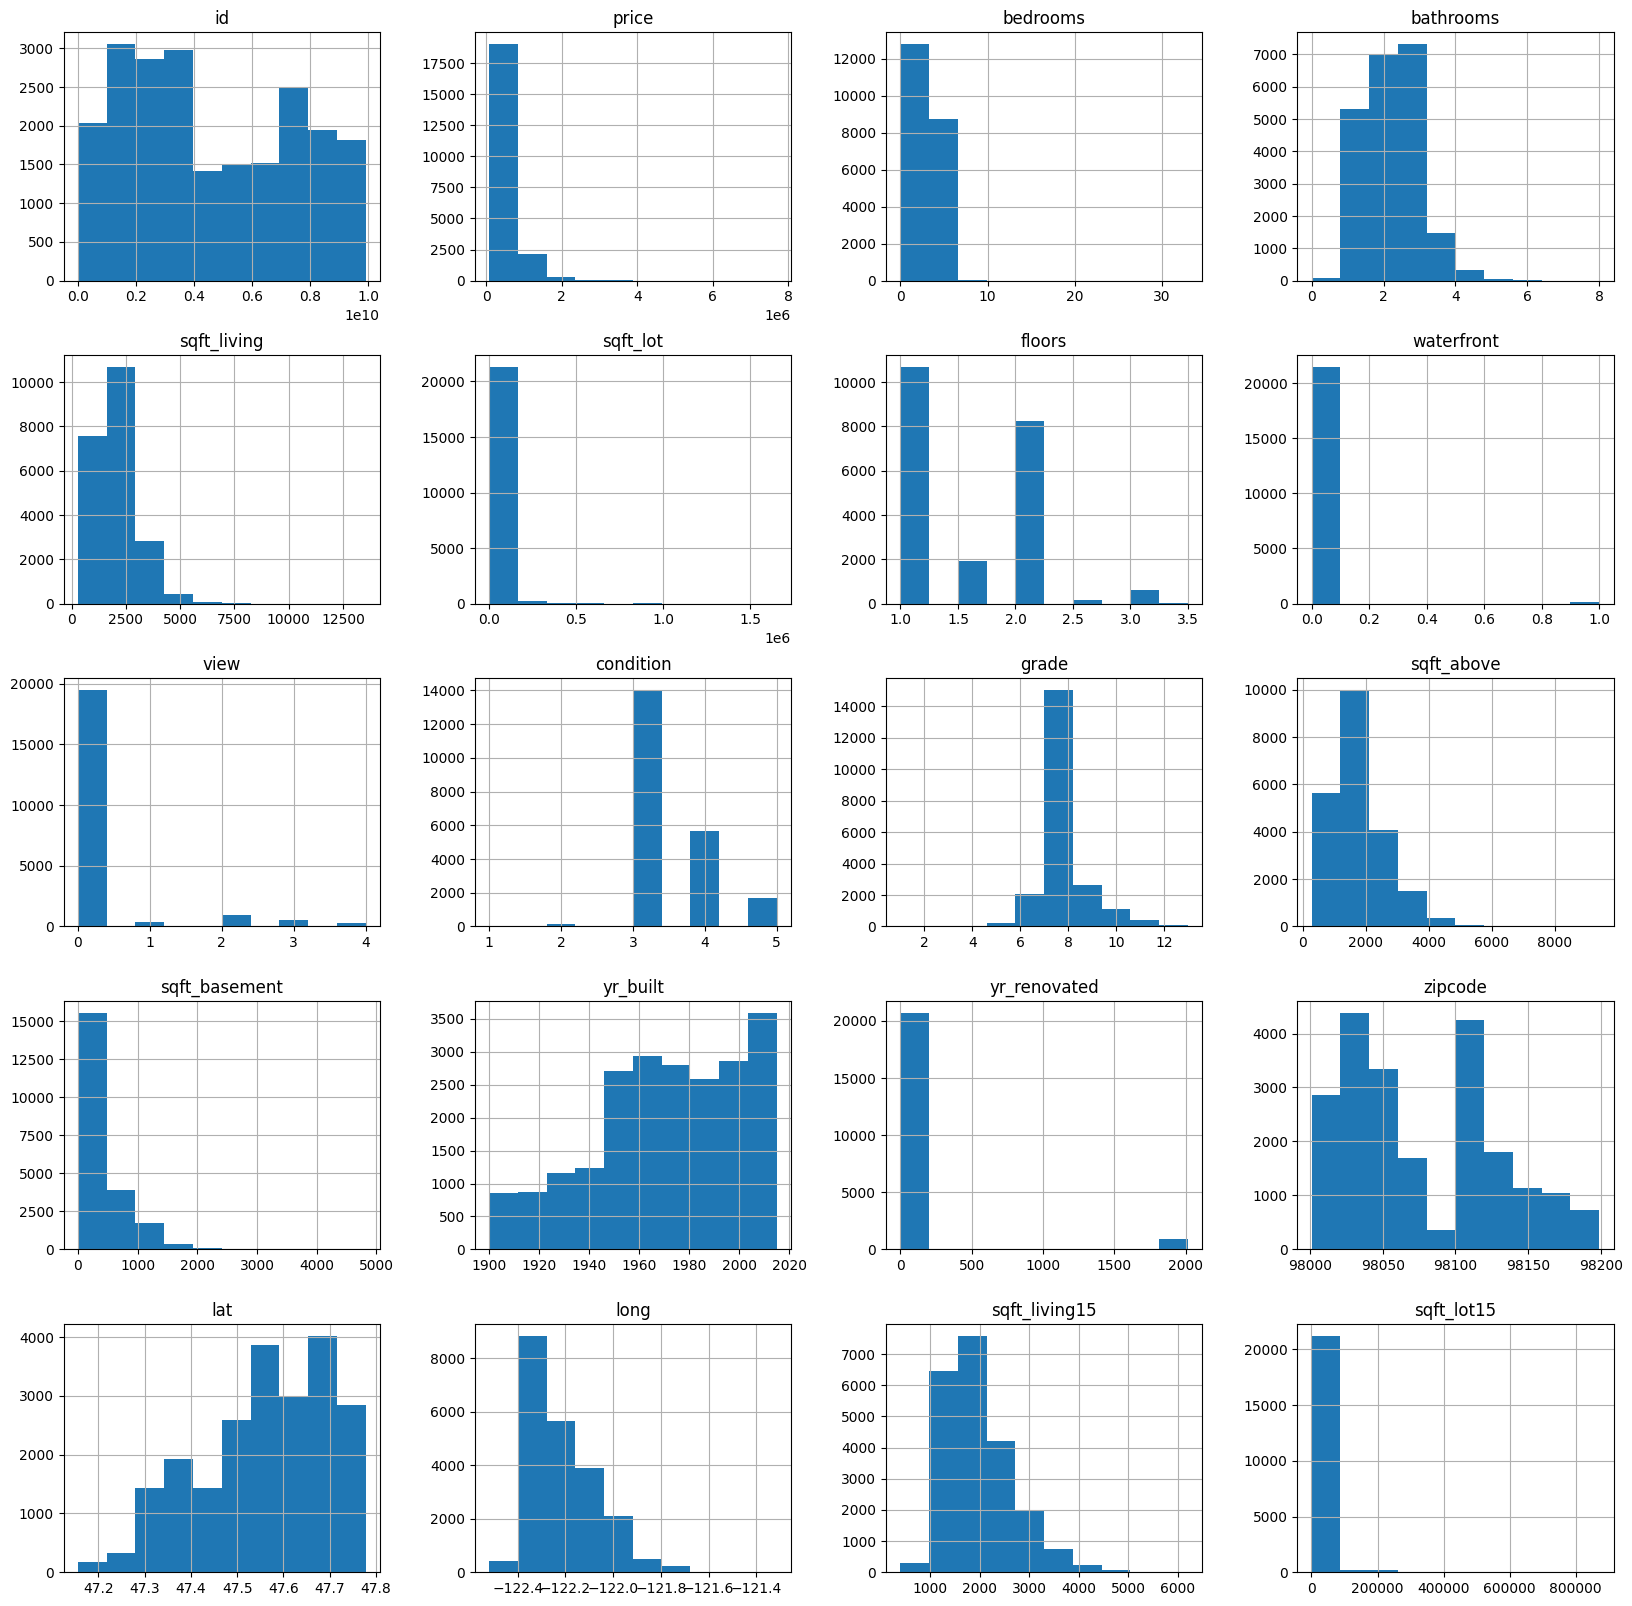

In [10]:
# Histogram plot
df.hist(figsize=(20,20))
plt.show()

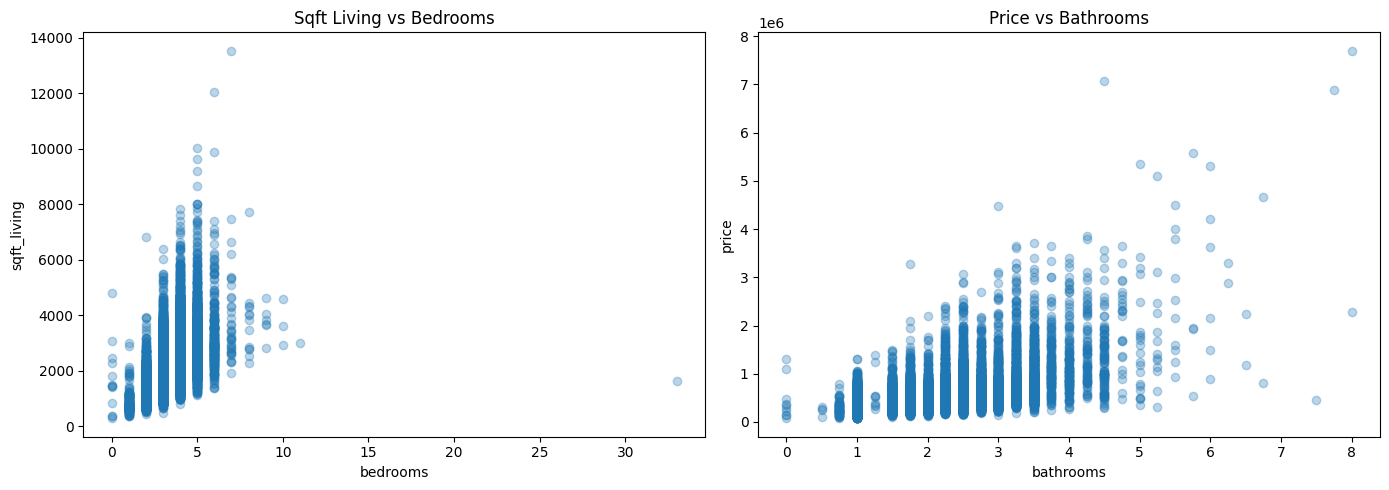

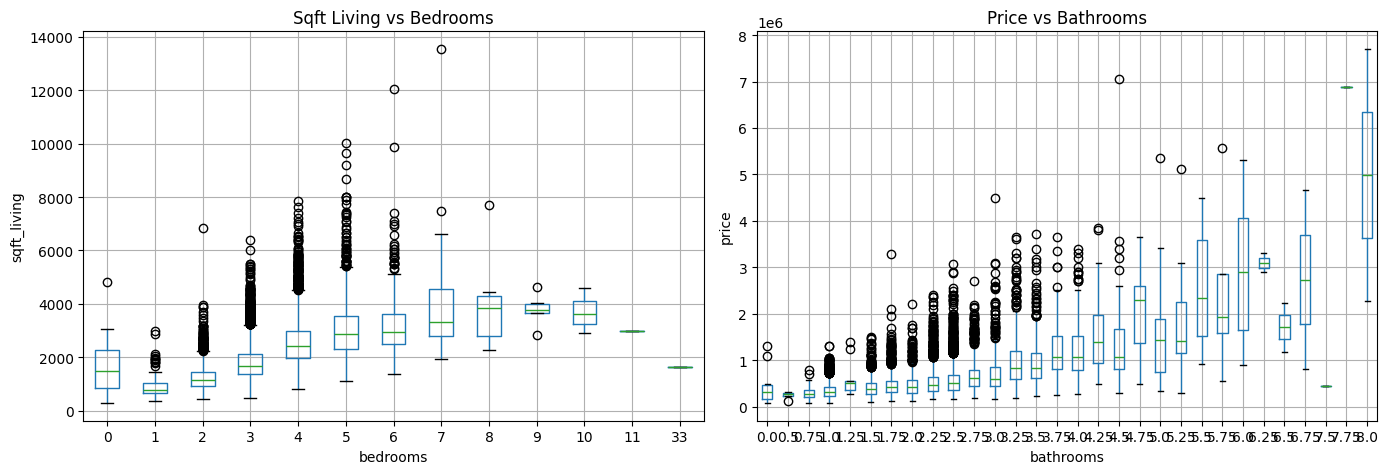

In [11]:
plots = [
    ('bedrooms', 'sqft_living',  'Sqft Living vs Bedrooms'),
    ('bathrooms', 'price', 'Price vs Bathrooms'),
]

def plot_scatters(df, plots, ncols=2, figsize=(14, 5)):
    """
    plots: list of (x_col, y_col, title) tuples
    """
    fig, axes = plt.subplots(1, ncols, figsize=figsize)
    axes = np.array([axes]).flatten()  # handles both single and multiple plots

    for ax, (x_col, y_col, title) in zip(axes, plots):
        ax.scatter(df[x_col], df[y_col], alpha=0.3)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

plot_scatters(df, plots)

def plot_boxplots(df, plots, figsize=(14, 5)):
    """
    plots: list of (x_col, y_col, title) tuples
    """
    fig, axes = plt.subplots(1, len(plots), figsize=figsize)
    axes = np.array([axes]).flatten()  # handles both single and multiple plots

    for ax, (x_col, y_col, title) in zip(axes, plots):
        df.boxplot(column=y_col, by=x_col, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

plot_boxplots(df, plots)

In [12]:
print("Houses with many bedrooms:")
print(df[df['bedrooms'] > 30][['bedrooms', 'bathrooms', 'sqft_living', 'price']])

print("\nHouses with no bathrooms:")
print(df[df['bathrooms'] == 0][['bedrooms', 'bathrooms', 'sqft_living', 'price']])

no_bath = (df['bathrooms'] == 0).sum()
print(f"\n{no_bath} houses without a bathroom")

Houses with many bedrooms:
       bedrooms  bathrooms  sqft_living     price
15870        33       1.75         1620  640000.0

Houses with no bathrooms:
       bedrooms  bathrooms  sqft_living      price
875           0        0.0         3064  1095000.0
1149          1        0.0          670    75000.0
3119          0        0.0         1470   380000.0
5832          1        0.0          600   280000.0
6994          0        0.0         4810  1295650.0
9773          0        0.0         2460   355000.0
9854          0        0.0         1470   235000.0
10481         1        0.0          690   484000.0
14423         0        0.0          844   139950.0
19452         0        0.0          290   142000.0

10 houses without a bathroom


In [13]:
outliers = df[(df['bathrooms'] == 0) | (df['bedrooms'] > 30) ]
print(f"Dropped {len(outliers)} houses")

df_out = df.drop(outliers.index)

Dropped 11 houses


In [14]:
df_mean = df.copy()

mean_bedrooms = round(df_mean['bedrooms'].mean())
df_mean.loc[df_mean['bedrooms'] > 30, 'bedrooms'] = mean_bedrooms

df_mean['bathrooms'] = df_mean['bathrooms'].replace(0,1)
#df_mean.loc[df_mean['bathrooms'] == 0, 'bathrooms'] = 1

In [15]:
#my basic and somewhat wrong version
#y = df['price']
#X = df.drop(columns=['price'])

#X_sc = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns)

#X_sc.describe()

#X_train, X_test, y_train, y_test = train_test_split(X_sc, y, test_size=0.2, random_state=42)

"""
models = [LinearRegression()]

for model in models:
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    cv_pred = cross_val_predict(model, X_train, y_train, cv=10)

    print(f"{model.__class__.__name__}")
    print(f"Train - R2: {r2_score(y_train, train_pred):.4f}, MAE:{mean_absolute_error(y_train, train_pred):.4f}, MAPE:{mean_absolute_percentage_error(y_train, train_pred):.4f}")
    print(f"CV - R2: {r2_score(y_train, cv_pred):.4f}, MAE:{mean_absolute_error(y_train, cv_pred):.4f}, MAPE:{mean_absolute_percentage_error(y_train, cv_pred):.4f}")
"""

'\nmodels = [LinearRegression()]\n\nfor model in models:\n    model.fit(X_train, y_train)\n    train_pred = model.predict(X_train)\n    cv_pred = cross_val_predict(model, X_train, y_train, cv=10)\n\n    print(f"{model.__class__.__name__}")\n    print(f"Train - R2: {r2_score(y_train, train_pred):.4f}, MAE:{mean_absolute_error(y_train, train_pred):.4f}, MAPE:{mean_absolute_percentage_error(y_train, train_pred):.4f}")\n    print(f"CV - R2: {r2_score(y_train, cv_pred):.4f}, MAE:{mean_absolute_error(y_train, cv_pred):.4f}, MAPE:{mean_absolute_percentage_error(y_train, cv_pred):.4f}")\n'

In [16]:
target = 'price'

dfs_names = {
    "Original": df,
    "Outliers removed": df_out,
    "Outliers replaced mean": df_mean
}

dfs = {
    name: (df.drop(columns=[target]), df[target])
    for name, df in dfs_names.items()
}

def prepare_dataset(X, y, test_size=0.2, random_state=42, scale=None, scale_y = False):
    #Ensure X is numeric
    X = X.select_dtypes(include='number')

    #Fit scaler on train only to avoid data leakage.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    if scale is not None:
        X_train = scale.fit_transform(X_train)
        X_test  = scale.transform(X_test)

        if scale_y:
            y_scaler = clone(scale)  # fresh scaler for y
            y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
            y_test  = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

    return {
        "Train": (X_train, y_train),
        "Test": (X_test, y_test)
    }

def adj_r2(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

def get_metrics(n_features):
    return {
        "R2" : r2_score,
        "Adj-R2": lambda y_true, y_pred: adj_r2(y_true, y_pred, n_features),
        "MAE": mean_absolute_error,
        "RMSE": root_mean_squared_error
    }

def evaluate_model(model, datasets, cv=10):
    #CV is  computed on the first dataset (assumed to be Train)

    first_name, (X_first, y_first) = next(iter(datasets.items()))
    model.fit(X_first, y_first)
    metrics = get_metrics(n_features=X_first.shape[1])

    predictions = {
        name: (y, model.predict(X))
        for name, (X,y) in datasets.items()
    }
    predictions[f"CV ({first_name})"] = (
        y_first,
        cross_val_predict(model, X_first, y_first, cv=cv)
    )

    for split_name, (y_true, y_pred) in predictions.items():
        scores = {name: fn(y_true, y_pred) for name, fn in metrics.items()}
        scores_str = ", ".join(f"{name}: {value:.4f}" for name, value in scores.items())
        print(f"    {split_name} - {scores_str}")

def run_experiments(raw_datasets, models, cv=10, scale=MinMaxScaler(), show_test=False, scale_y=False, test_size=0.2, random_state=42):
    for dataset_name, (X, y) in raw_datasets.items():
        print(f"\n{'='*60}")
        print(f"Dataset: {dataset_name}")
        print(f"{'='*60}")
        all_datasets = prepare_dataset(X, y, scale=scale)
        datasets = all_datasets if show_test else {"Train": all_datasets["Train"]}

        for model in models:
            print(f"\n {model.__class__.__name__}")
            evaluate_model(model, datasets, cv=cv)

models = [LinearRegression()] 

run_experiments(dfs, models, cv=10, show_test=False, scale=MinMaxScaler())


Dataset: Original

 LinearRegression
    Train - R2: 0.6992, Adj-R2: 0.6989, MAE: 125042.2552, RMSE: 198235.8750
    CV (Train) - R2: 0.6970, Adj-R2: 0.6967, MAE: 125256.4581, RMSE: 198957.4912

Dataset: Outliers removed

 LinearRegression
    Train - R2: 0.6991, Adj-R2: 0.6988, MAE: 125374.0054, RMSE: 200454.8277
    CV (Train) - R2: 0.6971, Adj-R2: 0.6968, MAE: 125567.0432, RMSE: 201115.4188

Dataset: Outliers replaced mean

 LinearRegression
    Train - R2: 0.6999, Adj-R2: 0.6996, MAE: 125065.7644, RMSE: 198015.7118
    CV (Train) - R2: 0.6980, Adj-R2: 0.6976, MAE: 125248.9341, RMSE: 198651.2742


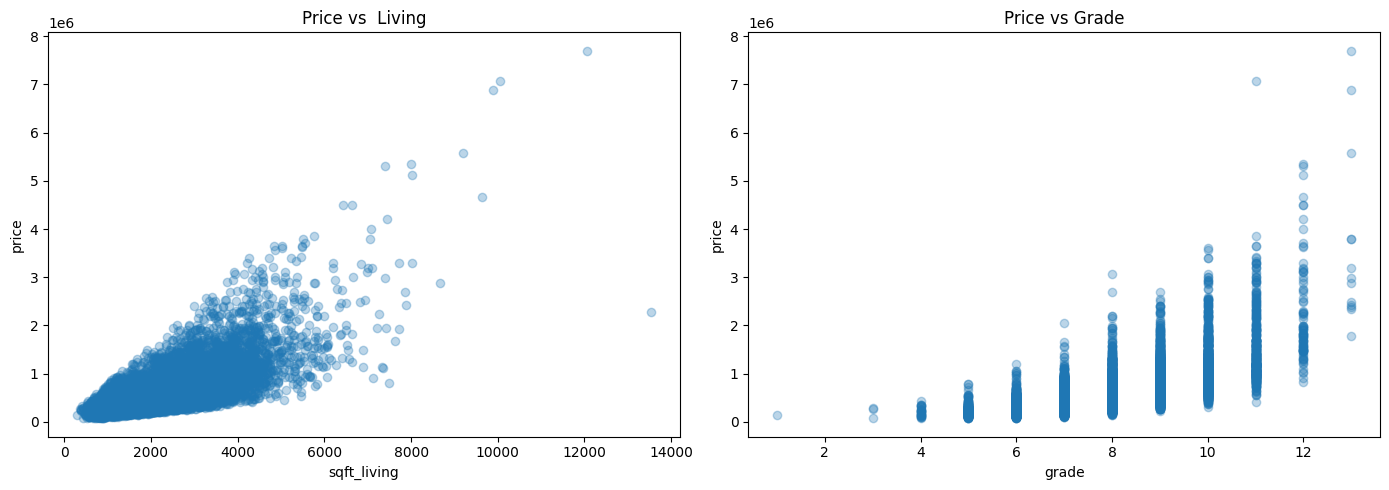

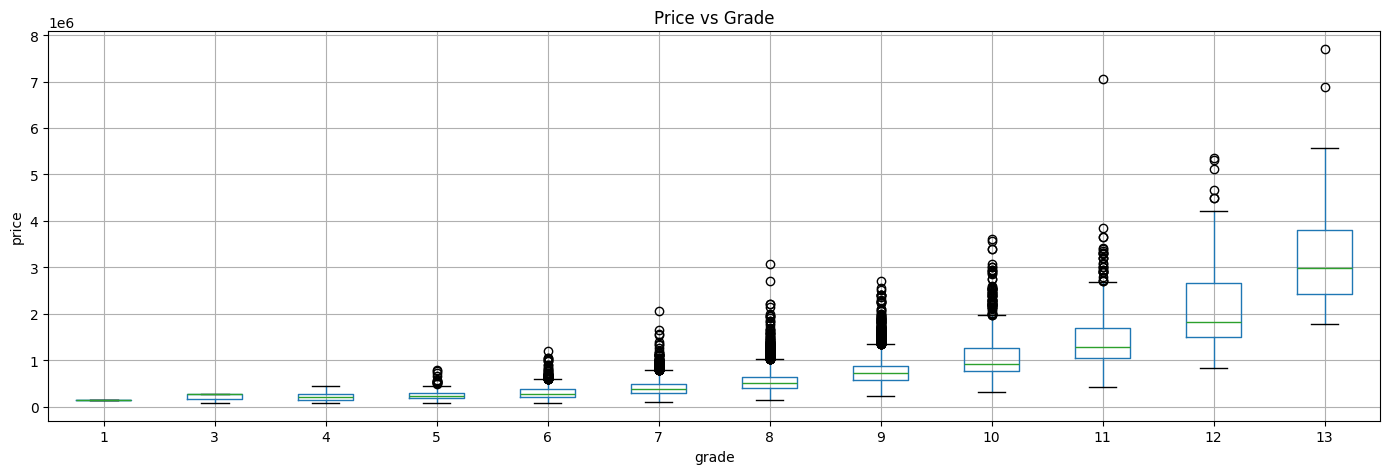

In [17]:
plots = [
    ('sqft_living', 'price',  'Price vs  Living'),
    ('grade', 'price', 'Price vs Grade'),
]

plot_scatters(df_mean, plots)
plot_boxplots(df_mean, [plots[1]])


In [18]:
dfs_preds_names = {
    "M1: sqft_living": df_mean[["price", "sqft_living"]],
    "M2: grade": df_mean[["price", "grade"]],
    "M3: sqft_living + grade": df_mean[["price", "sqft_living", "grade"]],
}

dfs_preds = {
    name: (df.drop(columns=[target]), df[target])
    for name, df in dfs_preds_names.items()
}

run_experiments(dfs_preds, models, cv=10, show_test=False, scale=None)


Dataset: M1: sqft_living

 LinearRegression
    Train - R2: 0.4924, Adj-R2: 0.4924, MAE: 172364.8001, RMSE: 257525.4313
    CV (Train) - R2: 0.4916, Adj-R2: 0.4915, MAE: 172397.0474, RMSE: 257733.0108

Dataset: M2: grade

 LinearRegression
    Train - R2: 0.4423, Adj-R2: 0.4423, MAE: 173833.1673, RMSE: 269919.0632
    CV (Train) - R2: 0.4419, Adj-R2: 0.4419, MAE: 173856.6272, RMSE: 270026.3113

Dataset: M3: sqft_living + grade

 LinearRegression
    Train - R2: 0.5333, Adj-R2: 0.5333, MAE: 163265.9524, RMSE: 246923.1311
    CV (Train) - R2: 0.5324, Adj-R2: 0.5324, MAE: 163307.4156, RMSE: 247161.9048


## Q5

In [19]:
#school version
#df[df.sqft_basement == 0].shape[0]

In [20]:
#more pythonic, %s
nos = {
    'sqft_basement': 'basement', 
    'yr_renovated': 'renovation'
}

for no, label in nos.items():
    pct = (df_mean[no] == 0).mean() * 100
    print(f"No {label}: {pct:.1f}%")

No basement: 60.7%
No renovation: 95.8%


Let's create features to see if the place was renovated or has a basement

In [21]:
for no, lab in nos.items():
    df_mean[lab] = (df[no]>0).astype(int)

In [22]:
df_mean.shape

(21613, 23)

In [23]:
df_mean

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,basement,renovation
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,5650,0,0
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,1,1
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,8062,0,0
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,1,0
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,0,1987,0,98074,47.6168,-122.045,1800,7503,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,0,2009,0,98103,47.6993,-122.346,1530,1509,0,0
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,0,2014,0,98146,47.5107,-122.362,1830,7200,0,0
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,0,2009,0,98144,47.5944,-122.299,1020,2007,0,0
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,0,2004,0,98027,47.5345,-122.069,1410,1287,0,0


In [24]:
predictors = ['bedrooms', 'bathrooms', 'floors']

dfs_preds_names = {
    "M1: baseline": df_mean[["price"] + predictors],
    "M2: + non-binary" : df_mean[["price"] + predictors + ['sqft_basement', 'yr_renovated']],
    "M3: + binary": df_mean[["price"] + predictors + ['sqft_basement', 'yr_renovated', 'basement', 'renovation']],
}

dfs_preds = {
    name: (df.drop(columns=[target]), df[target])
    for name, df in dfs_preds_names.items()
}

run_experiments(dfs_preds, models, cv=10, show_test=False, scale=MinMaxScaler())


Dataset: M1: baseline

 LinearRegression
    Train - R2: 0.2798, Adj-R2: 0.2796, MAE: 201203.2565, RMSE: 306753.4373
    CV (Train) - R2: 0.2790, Adj-R2: 0.2789, MAE: 201287.3156, RMSE: 306919.8129

Dataset: M2: + non-binary

 LinearRegression
    Train - R2: 0.3257, Adj-R2: 0.3255, MAE: 195896.2584, RMSE: 296816.7766
    CV (Train) - R2: 0.3245, Adj-R2: 0.3243, MAE: 195991.1106, RMSE: 297073.0246

Dataset: M3: + binary

 LinearRegression
    Train - R2: 0.3326, Adj-R2: 0.3323, MAE: 195496.5566, RMSE: 295287.8538
    CV (Train) - R2: 0.3310, Adj-R2: 0.3308, MAE: 195616.9596, RMSE: 295633.3492


# Q6

In [25]:
predictors = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_living15', 'sqft_lot15']

dfs_knn = {"KNN": (df_mean[predictors], df_mean[target])}
models_knn = [KNeighborsRegressor()]

for scaler in [MinMaxScaler(), StandardScaler()]:
    print(f"\n=== Scaler: {scaler.__class__.__name__} ===")
    run_experiments(dfs_knn, models_knn, scale=scaler, scale_y=True, 
                    test_size=0.33, random_state=8, show_test=False)


=== Scaler: MinMaxScaler ===

Dataset: KNN

 KNeighborsRegressor
    Train - R2: 0.6944, Adj-R2: 0.6943, MAE: 129214.1862, RMSE: 199815.5166
    CV (Train) - R2: 0.5287, Adj-R2: 0.5286, MAE: 159560.8185, RMSE: 248138.1253

=== Scaler: StandardScaler ===

Dataset: KNN

 KNeighborsRegressor
    Train - R2: 0.7096, Adj-R2: 0.7095, MAE: 124380.8194, RMSE: 194784.6102
    CV (Train) - R2: 0.5596, Adj-R2: 0.5595, MAE: 153175.2902, RMSE: 239859.5159


# Q7

In [26]:
ordinal_predictors = ['bedrooms', 'bathrooms', 'floors','waterfront', 'view', 'condition', 'grade']
sqft_variables = ['sqft_living', 'sqft_lot','sqft_above', 'sqft_living15','sqft_lot15']

# Create log variables
log_variables = []
for p in sqft_variables:
    var_name = 'log_' + p
    log_variables.append(var_name)
    df_mean[var_name] = np.log(df_mean[p] + 1)

df_mean['log_price'] = np.log(df_mean['price'] + 1)

# Datasets
dfs_log_names = {
    "M1: ordinal + sqft":     df_mean[['price'] + ordinal_predictors + sqft_variables],
    "M2: log_price + ordinal + log_sqft": df_mean[['log_price'] + ordinal_predictors + log_variables],
}

dfs_log = {
    name: (df.drop(columns=[df.columns[0]]), df[df.columns[0]])
    for name, df in dfs_log_names.items()
}

models_log = [LinearRegression(), KNeighborsRegressor()]

run_experiments(dfs_log, models_log, scale_y=True, scale = None, 
                test_size=0.33, random_state=8, show_test=False)


Dataset: M1: ordinal + sqft

 LinearRegression
    Train - R2: 0.6044, Adj-R2: 0.6041, MAE: 150559.9499, RMSE: 227341.8018
    CV (Train) - R2: 0.6026, Adj-R2: 0.6023, MAE: 150702.0772, RMSE: 227854.0437

 KNeighborsRegressor
    Train - R2: 0.6645, Adj-R2: 0.6643, MAE: 128698.3723, RMSE: 209354.8898
    CV (Train) - R2: 0.4866, Adj-R2: 0.4862, MAE: 158684.8645, RMSE: 258994.6218

Dataset: M2: log_price + ordinal + log_sqft

 LinearRegression
    Train - R2: 0.6007, Adj-R2: 0.6004, MAE: 0.2655, RMSE: 0.3316
    CV (Train) - R2: 0.6000, Adj-R2: 0.5997, MAE: 0.2657, RMSE: 0.3319

 KNeighborsRegressor
    Train - R2: 0.7494, Adj-R2: 0.7492, MAE: 0.2037, RMSE: 0.2627
    CV (Train) - R2: 0.6180, Adj-R2: 0.6178, MAE: 0.2517, RMSE: 0.3244


# Q8

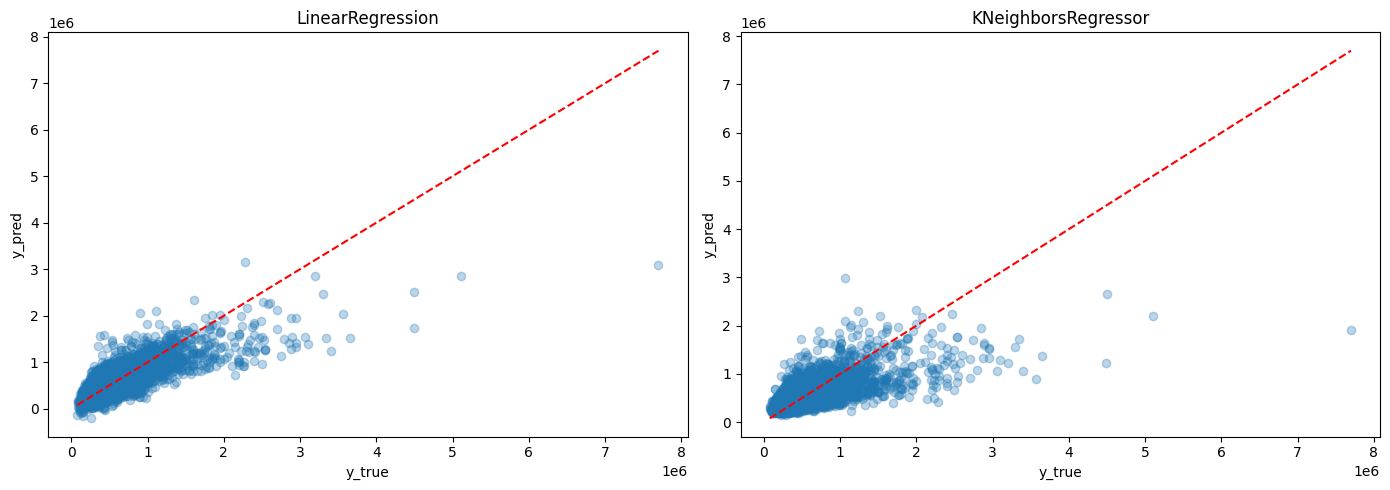

In [27]:
def plot_predictions(models, X_train, X_test, y_test):
    fig, axes = plt.subplots(1, len(models), figsize=(14, 5))
    axes = np.array([axes]).flatten()

    for ax, model in zip(axes, models):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        ax.scatter(y_test, y_pred, alpha=0.3)
        ax.plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
        ax.set_xlabel('y_true')
        ax.set_ylabel('y_pred')
        ax.set_title(model.__class__.__name__)

    plt.tight_layout()
    plt.show()

# Usage — non-scaled, non-transformed
predictors = ordinal_predictors + sqft_variables
datasets = prepare_dataset(df[predictors], df[target], 
                           test_size=0.33, random_state=8, scale=None)

X_train, y_train = datasets['Train']
X_test,  y_test  = datasets['Test']

plot_predictions([LinearRegression(), KNeighborsRegressor()], X_train, X_test, y_test)

# Last Q

In [28]:
predictors_log = ordinal_predictors + log_variables
target_log     = 'log_price'

dfs_k = {"Log variables": (df_mean[predictors_log], df_mean[target_log])}

models_k = [KNeighborsRegressor(n_neighbors=k, weights='uniform') for k in range(1, 17)]

run_experiments(dfs_k, models_k, scale=None, test_size=0.33, random_state=8, show_test=False)


Dataset: Log variables

 KNeighborsRegressor
    Train - R2: 0.9938, Adj-R2: 0.9938, MAE: 0.0029, RMSE: 0.0414
    CV (Train) - R2: 0.3899, Adj-R2: 0.3895, MAE: 0.3118, RMSE: 0.4099

 KNeighborsRegressor
    Train - R2: 0.8481, Adj-R2: 0.8480, MAE: 0.1554, RMSE: 0.2045
    CV (Train) - R2: 0.5364, Adj-R2: 0.5360, MAE: 0.2756, RMSE: 0.3574

 KNeighborsRegressor
    Train - R2: 0.7952, Adj-R2: 0.7951, MAE: 0.1829, RMSE: 0.2375
    CV (Train) - R2: 0.5808, Adj-R2: 0.5805, MAE: 0.2628, RMSE: 0.3398

 KNeighborsRegressor
    Train - R2: 0.7663, Adj-R2: 0.7661, MAE: 0.1961, RMSE: 0.2537
    CV (Train) - R2: 0.6049, Adj-R2: 0.6046, MAE: 0.2557, RMSE: 0.3299

 KNeighborsRegressor
    Train - R2: 0.7494, Adj-R2: 0.7492, MAE: 0.2037, RMSE: 0.2627
    CV (Train) - R2: 0.6180, Adj-R2: 0.6178, MAE: 0.2517, RMSE: 0.3244

 KNeighborsRegressor
    Train - R2: 0.7362, Adj-R2: 0.7361, MAE: 0.2091, RMSE: 0.2695
    CV (Train) - R2: 0.6266, Adj-R2: 0.6263, MAE: 0.2493, RMSE: 0.3207

 KNeighborsRegressor


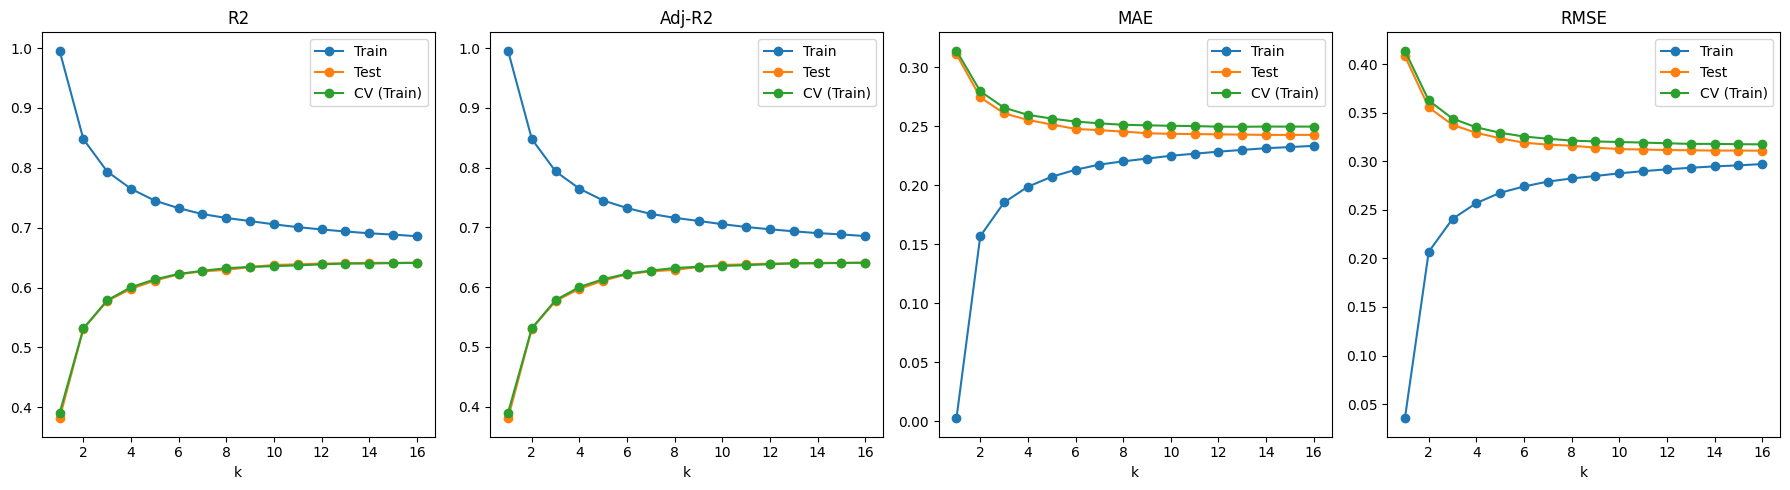

In [29]:
def get_scores(model, datasets):
    """Same as evaluate_model but returns scores instead of printing."""
    first_name, (X_first, y_first) = next(iter(datasets.items()))
    model.fit(X_first, y_first)
    metrics = get_metrics(n_features=X_first.shape[1])

    predictions = {
        name: (y, model.predict(X))
        for name, (X, y) in datasets.items()
    }
    predictions[f"CV ({first_name})"] = (
        y_first,
        cross_val_predict(model, X_first, y_first, cv=10)
    )

    return {
        split_name: {name: fn(y_true, y_pred) for name, fn in metrics.items()}
        for split_name, (y_true, y_pred) in predictions.items()
    }

def plot_k_scores(datasets, k_range=range(1, 17)):
    results = {}
    for k in k_range:
        model = KNeighborsRegressor(n_neighbors=k, weights='uniform')
        _, (X, y) = next(iter(datasets.items()))
        splits   = prepare_dataset(X, y, scale=None, test_size=0.33, random_state=8)
        results[k] = get_scores(model, splits)

    metrics = ['R2', 'Adj-R2', 'MAE', 'RMSE']
    splits  = list(next(iter(results.values())).keys())

    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))
    for ax, metric in zip(axes, metrics):
        for split in splits:
            scores = [results[k][split][metric] for k in k_range]
            ax.plot(list(k_range), scores, marker='o', label=split)
        ax.set_title(metric)
        ax.set_xlabel('k')
        ax.legend()

    plt.tight_layout()
    plt.show()

# Usage
plot_k_scores(dfs_k)